# Análise Exploratória — UTKFace

Esta seção apresenta uma análise exploratória do conjunto UTKFace com ênfase
na caracterização estatística das variáveis demográficas extraídas dos nomes
dos arquivos. O objetivo é estabelecer uma base empírica para decisões
posteriores de pré-processamento, balanceamento e avaliação de modelos.

Objetivos específicos:
- Caracterizar a distribuição marginal de idade, gênero e raça
- Identificar assimetrias e concentrações que possam introduzir vieses
- Produzir métricas e visualizações que sustentem decisões metodológicas


## 1. Fonte e estrutura dos dados

**Decisão técnica:** manter a leitura a partir de diretório local para garantir
reprodutibilidade e independência de credenciais externas. Essa opção
minimiza variações de ambiente e facilita a execução do notebook em diferentes
plataformas.

O UTKFace codifica metadados no nome do arquivo com o padrão
`[idade]_[genero]_[raça]_[data&hora].jpg`. Nesta etapa, extraímos apenas os
três primeiros tokens (idade, gênero, raça), descartando o timestamp. Tal
recorte é suficiente para as análises estatísticas pretendidas e evita
introduzir variáveis temporais que não serão utilizadas no pipeline atual.


In [102]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Estilo de plots
sns.set_theme(style="whitegrid")

In [103]:
# DataFrame principal
df = pd.DataFrame(records)

# Resumo rápido (formatação)
resumo_df = pd.DataFrame({
    "total_imagens": [len(df)],
    "arquivos_nao_jpg": [skipped["nao_jpg"]],
    "nomes_malformados": [skipped["malformado"]],
    "erros_parse": [skipped["parse_erro"]],
})

resumo_df = resumo_df.T.rename(columns={0: "valor"})

display(resumo_df.style.set_caption("RESUMO DO CARREGAMENTO"))

display(df.head())

,valor
total_imagens,23705
arquivos_nao_jpg,0
nomes_malformados,0
erros_parse,3


,idade,genero,raca,arquivo
0,56,0,3,56_0_3_20170105180725694.jpg.chip.jpg
1,70,1,1,70_1_1_20170110153248874.jpg.chip.jpg
2,88,1,0,88_1_0_20170120133811095.jpg.chip.jpg
3,19,1,1,19_1_1_20170114030824961.jpg.chip.jpg
4,8,0,2,8_0_2_20170110220614569.jpg.chip.jpg


## 2. Documentação das classes

**Decisão técnica:** agregar idades em faixas para reduzir granularidade e
variância amostral. A discretização em macroestágios do ciclo de vida
facilita comparações intergrupos e fornece uma base consistente para
avaliações por classe.

- **Faixa etária**:
  - Criança Pequena: 0–5
  - Criança: 6–12
  - Adolescente: 13–19
  - Jovem adulto: 20–29
  - Adulto: 30–59
  - Idoso: 60–120
- **Gênero**:
  - 0: Masculino
  - 1: Feminino
- **Raça/Etnia**:
  - 0: Branco
  - 1: Negro
  - 2: Asiático
  - 3: Indiano
  - 4: Outro

A padronização de rótulos é necessária para garantir consistência nas
visualizações, tabelas de contingência e métricas de desequilíbrio.


In [104]:
# Mapas de rótulos
genero_map = {0: "Masculino", 1: "Feminino"}
raca_map = {
    0: "Branco",
    1: "Negro",
    2: "Asiático",
    3: "Indiano",
    4: "Outro",
}

# Faixas etárias
bins = [0, 5, 12, 19, 29, 59, 120]
labels = [
    "Criança Pequena",
    "Criança",
    "Adolescente",
    "Jovem adulto",
    "Adulto",
    "Idoso",
]

# Colunas derivadas
df["genero_label"] = df["genero"].map(genero_map)
df["raca_label"] = df["raca"].map(raca_map)
df["faixa_etaria"] = pd.cut(
    df["idade"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True,
)

## 3. Métrica de densidade

**Decisão técnica:** definir a densidade global como a média de imagens por
idade observada, fornecendo uma medida simples de concentração. Além disso,
calculamos a distribuição normalizada por idade para identificar picos e
regiões subamostradas.

Essa métrica é particularmente útil para indicar se há um desbalanceamento de faixas etárias específicas, o que pode impactar a generalização do modelo
para idades menos frequentes.


In [105]:
idade_min = df["idade"].min()
idade_max = df["idade"].max()
intervalo_idades = idade_max - idade_min + 1

# Densidade global
densidade_global = len(df) / intervalo_idades

# Densidade por idade
densidade_por_idade = df["idade"].value_counts().sort_index() / len(df)

resumo_densidade = pd.DataFrame({
    "total_imagens": [len(df)],
    "idade_min": [idade_min],
    "idade_max": [idade_max],
    "intervalo_idades": [intervalo_idades],
    "densidade_global": [densidade_global],
})

resumo_densidade = resumo_densidade.T.rename(columns={0: "valor"})

# Idades mais densas
top5_idades_densas = densidade_por_idade.sort_values(ascending=False).head(5)

# Frufru do python pra ficar uma tabela massa
display(resumo_densidade.style.format({"valor": "{:.4f}"}).set_caption("RESUMO DE DENSIDADE"))
display(top5_idades_densas.rename("proporcao").to_frame().style.format({"proporcao": "{:.4f}"}).set_caption("IDADES MAIS DENSAS"))


,valor
total_imagens,23705.0000
idade_min,1.0000
idade_max,116.0000
intervalo_idades,116.0000
densidade_global,204.3534


,proporcao
idade,
26,0.0927
1,0.0474
28,0.0387
35,0.0371
24,0.0362


## 4. Distribuição de idades

**Decisão técnica:** utilizar histograma com bins moderados para evidenciar
assimetrias, caudas e concentrações sem excesso de ruído visual. A escolha
por bins intermediários preserva o padrão global sem mascarar variações
relevantes no intervalo etário.


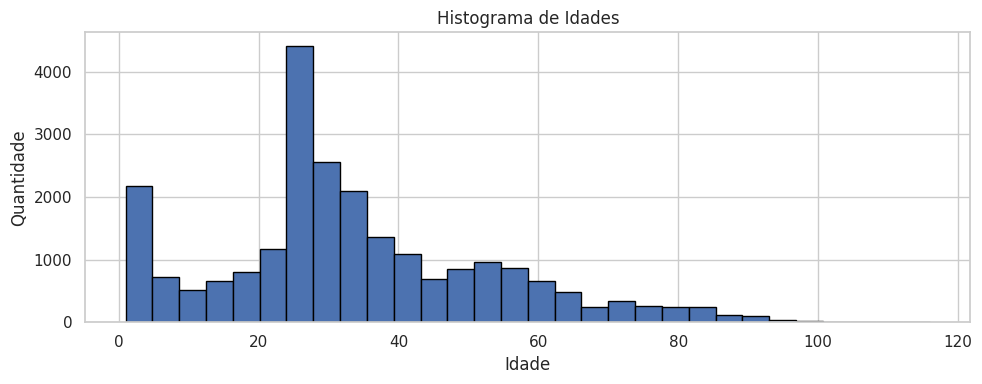

In [106]:
plt.figure(figsize=(10, 4))
plt.hist(df["idade"], bins=30, edgecolor="black")
plt.title("Histograma de Idades")
plt.xlabel("Idade")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()


## 5. Distribuição por classes (faixa etária)

**Decisão técnica:** analisar faixas etárias permite quantificar o desequilíbrio
a nível de classe, um fator crítico para desempenho, calibração e estabilidade
do treinamento supervisionado. Esta análise oferece uma visão direta de
quais classes demandariam estratégias de reamostragem ou ponderação.


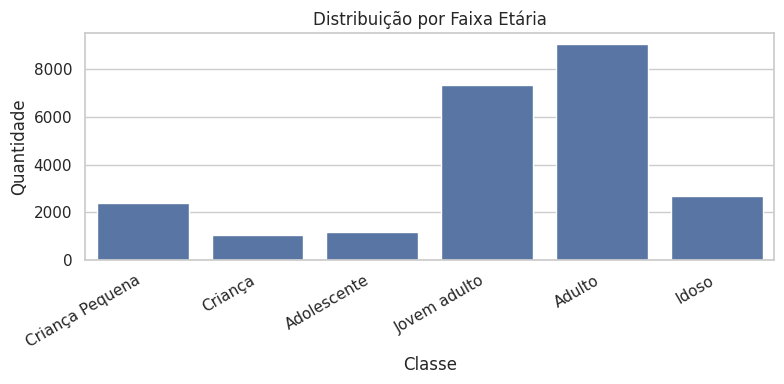

In [107]:
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="faixa_etaria",
    order=df["faixa_etaria"].value_counts().sort_index().index,
)
plt.title("Distribuição por Faixa Etária")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 6. Distribuição por gênero e raça

**Decisão técnica:** avaliar marginais antes de cruzamentos evita confundir
desequilíbrio global com padrões condicionais. Esta etapa fornece uma leitura
clara da representatividade de cada atributo isoladamente.


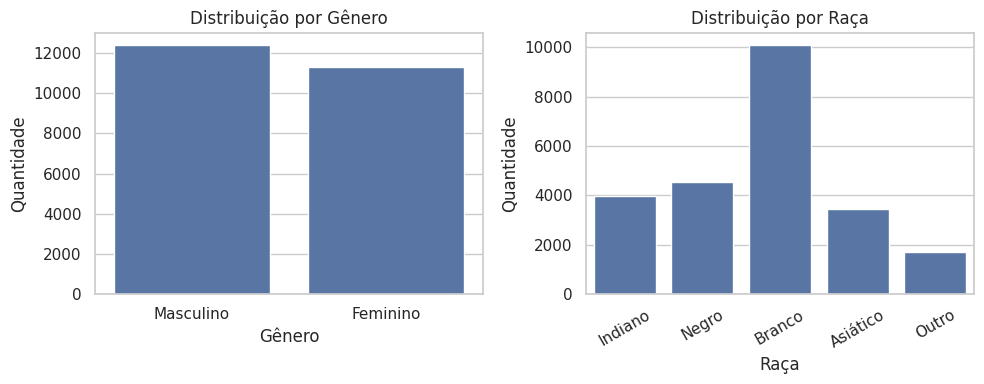

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df, x="genero_label", ax=axes[0])
axes[0].set_title("Distribuição por Gênero")
axes[0].set_xlabel("Gênero")
axes[0].set_ylabel("Quantidade")

sns.countplot(data=df, x="raca_label", ax=axes[1])
axes[1].set_title("Distribuição por Raça")
axes[1].set_xlabel("Raça")
axes[1].set_ylabel("Quantidade")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 7. Heatmaps (idade x gênero / idade x raça)

**Decisão técnica:** heatmaps evidenciam concentrações por subgrupo e
permitem identificar padrões condicionais que não são visíveis em
projeções marginais. Esta visualização é útil para antecipar possíveis
vieses interseccionais.


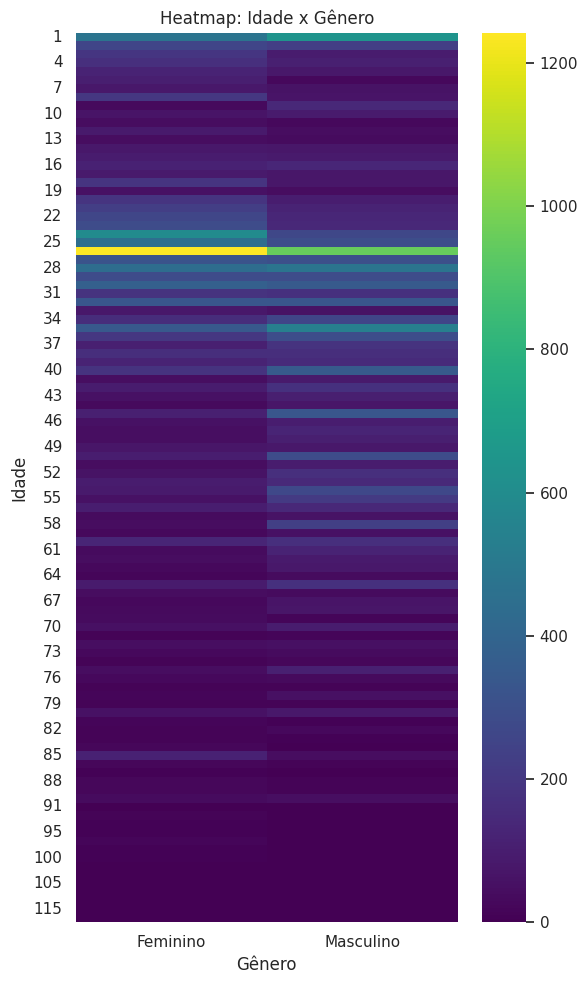

In [109]:
# Heatmap idade x gênero
idade_genero = pd.crosstab(df["idade"], df["genero_label"])
plt.figure(figsize=(6, 10))
sns.heatmap(idade_genero, cmap="viridis", cbar=True)
plt.title("Heatmap: Idade x Gênero")
plt.xlabel("Gênero")
plt.ylabel("Idade")
plt.tight_layout()
plt.show()


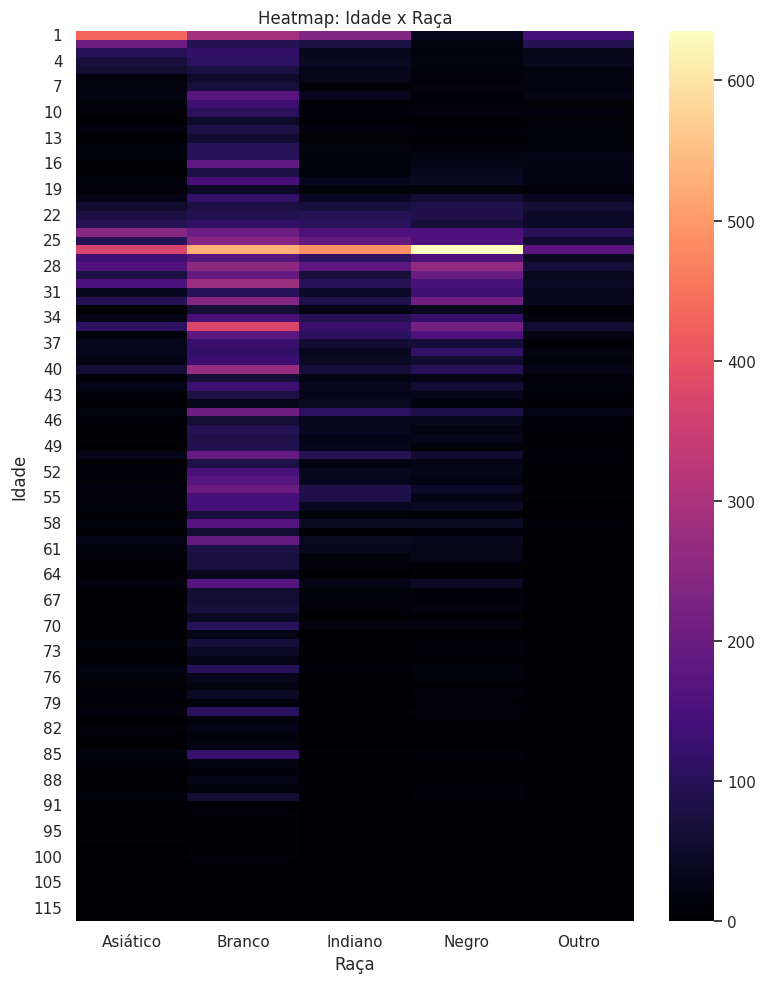

In [110]:
# Heatmap idade x raça
idade_raca = pd.crosstab(df["idade"], df["raca_label"])
plt.figure(figsize=(8, 10))
sns.heatmap(idade_raca, cmap="magma", cbar=True)
plt.title("Heatmap: Idade x Raça")
plt.xlabel("Raça")
plt.ylabel("Idade")
plt.tight_layout()
plt.show()


## 8. Tabelas de contingência

**Decisão técnica:** as tabelas resumem interações discretas entre classes e
funcionam como base quantitativa para estratégias de balanceamento,
reamostragem ou definição de pesos de perda.


In [111]:
# Faixa etária x gênero
faixa_genero = pd.crosstab(df["faixa_etaria"], df["genero_label"])

# Raça x gênero
raca_genero = pd.crosstab(df["raca_label"], df["genero_label"])

# Exibição formatada
display(faixa_genero.style.set_caption("Faixa etária x gênero"))
display(raca_genero.style.set_caption("Raça x gênero"))


genero_label,Feminino,Masculino
faixa_etaria,,
Criança Pequena,1207,1156
Criança,599,451
Adolescente,659,521
Jovem adulto,4282,3062
Adulto,3425,5655
Idoso,1142,1546


genero_label,Feminino,Masculino
raca_label,,
Asiático,1859,1575
Branco,4601,5477
Indiano,1714,2261
Negro,2208,2318
Outro,932,760


## 9. Insights

In [112]:
# Insights automáticos a partir das distribuições
faixa_counts = df["faixa_etaria"].value_counts()
genero_counts = df["genero_label"].value_counts()
raca_counts = df["raca_label"].value_counts()

faixa_ratio = faixa_counts.max() / max(faixa_counts.min(), 1)
genero_ratio = genero_counts.max() / max(genero_counts.min(), 1)
raca_ratio = raca_counts.max() / max(raca_counts.min(), 1)

idade_top5_share = densidade_por_idade.sort_values(ascending=False).head(5).sum()

insights = [
    f"Faixa etária mais frequente: {faixa_counts.idxmax()} (razão max/min = {faixa_ratio:.2f} aprox.).",
    f"Gênero mais frequente: {genero_counts.idxmax()} (razão max/min = {genero_ratio:.2f} aprox.).",
    f"Raça mais frequente: {raca_counts.idxmax()} (razão max/min = {raca_ratio:.2f} aprox.).",
    f"As 5 idades mais frequentes somam ~{idade_top5_share:.2%} do dataset.",
]

insights_df = pd.DataFrame({"insight": insights})
display(insights_df.style.set_caption("Insights gerados automaticamente"))


,insight
0,Faixa etária mais frequente: Adulto (razão max/min = 8.65 aprox.).
1,Gênero mais frequente: Masculino (razão max/min = 1.10 aprox.).
2,Raça mais frequente: Branco (razão max/min = 5.96 aprox.).
3,As 5 idades mais frequentes somam ~25.21% do dataset.
